# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [3]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [4]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
df_missing = df.isnull().mean() * 100
print(df_missing)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì mục tiêu là dự đoán cột 'survived' mà cột 'alive' chính là thông tin 'survived' được viết bằng chữ. Nếu giữ 'alive' mô hình chỉ cần nhìn cột 'alive' là sẽ dự đoán được survived, nó sẽ không học các mối quan hệ giữa các cột khác với nhau.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [5]:
# TODO 2: shape, info, describe
rows = df.shape[0]
cols = df.shape[1]
print(f"Shape: {rows} rows, {cols} columns")
df.info()
df.describe()

Shape: 891 rows, 8 columns
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.describe(include="object")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12688\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- Biến số: age, sibsp, parch, fare
- Biến phân loại: sex, embarked, pclass, survived

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [7]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100
missing_table = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing Percent' : missing_percent   
})
display(missing_table)

,Missing Count,Missing Percent
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do                 
-  age | ~20% | Lấy median của cột điền vào các ô bị thiếu | Meadian không bị ảnh hưởng bởi các outliers

- embarked | ~0.2% | Lấy mode của cột điền vào các ô bị thiếu | Đây là biến phân loại, lấy biến có xác suất xuất hiện nhiều nhất trong cột để điền vào sẽ giảm thiểu việc dữ liệu sai thực tế

In [8]:
median = df['age'].median()
df['age'] = df['age'].fillna(median)

mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode)

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

<Axes: xlabel='age'>

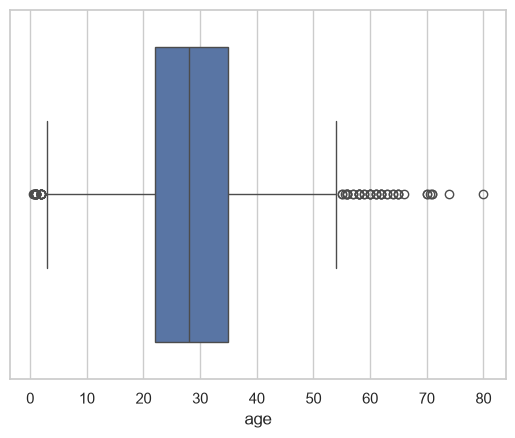

In [9]:
sns.boxplot(x=df['age'])

<Axes: xlabel='fare'>

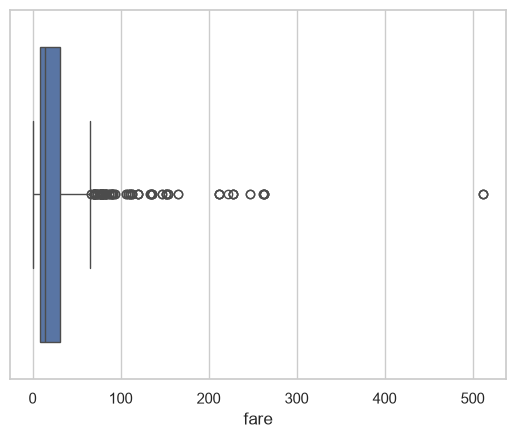

In [10]:
sns.boxplot(x=df['fare'])

In [11]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
     Q1 = df[s].quantile(0.25)
     Q3 = df[s].quantile(0.75)
     IQR = Q3 - Q1
     lower_pound = Q1 - 1.5*IQR
     upper_pound = Q3 + 1.5*IQR
     return len(df[(df[s] < lower_pound ) | (df[s] > upper_pound)])  # trả về số lượng outlier theo IQR

from scipy import stats

def dem_outlier_zscore(s, nguong=3.0):
     z_scores = stats.zscore(df[s])
     return len(df[abs(z_scores) > nguong]) # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    outlier_iqr = dem_outlier_iqr(col)
    outlier_zscore = dem_outlier_zscore(col)
    print(f"Outliers in '{col}' using IQR: {outlier_iqr}")
    print(f"Outliers in '{col}' using Z-score: {outlier_zscore}")

Outliers in 'age' using IQR: 66
Outliers in 'age' using Z-score: 7
Outliers in 'fare' using IQR: 116
Outliers in 'fare' using Z-score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Dụa vào 2 bảng phía dưới, em sẽ giữ lại các outlier của 'fare', bởi vì vé đắt bất thường là do đa số các vé thuộc hạng nhất

In [12]:
def outlier_iqr(s):
     Q1 = df[s].quantile(0.25)
     Q3 = df[s].quantile(0.75)
     IQR = Q3 - Q1
     lower_pound = Q1 - 1.5*IQR
     upper_pound = Q3 + 1.5*IQR
     return df[(df[s] < lower_pound ) | (df[s] > upper_pound)]

outlier_iqr = outlier_iqr('fare')
fare_outliers_table = outlier_iqr[['fare', 'pclass']]
display(fare_outliers_table)
print(outlier_iqr['pclass'].value_counts())

,fare,pclass
1,71.2833,1
27,263.0000,1
31,146.5208,1
34,82.1708,1
52,76.7292,1
...,...,...
846,69.5500,3
849,89.1042,1
856,164.8667,1
863,69.5500,3


pclass
1    104
3      7
2      5
Name: count, dtype: int64


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

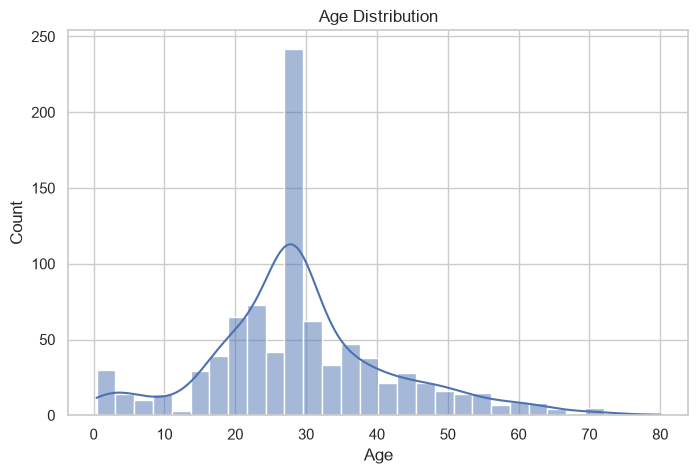

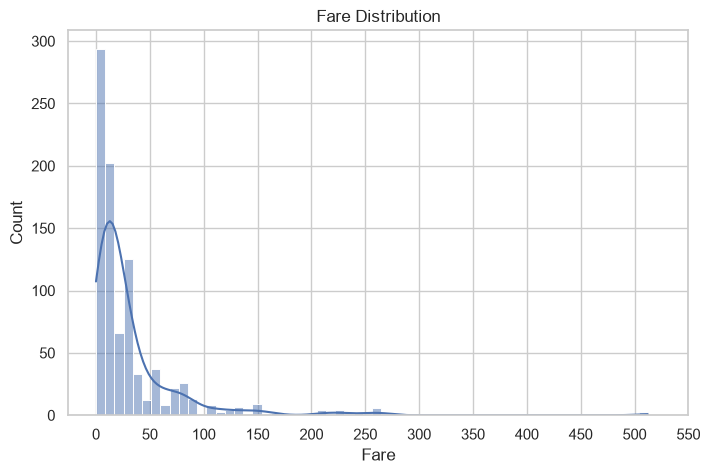

In [13]:
# TODO 5a: Histogram age & fare
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='fare', kde=True)
plt.xticks(np.arange(0, 600, 50))
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

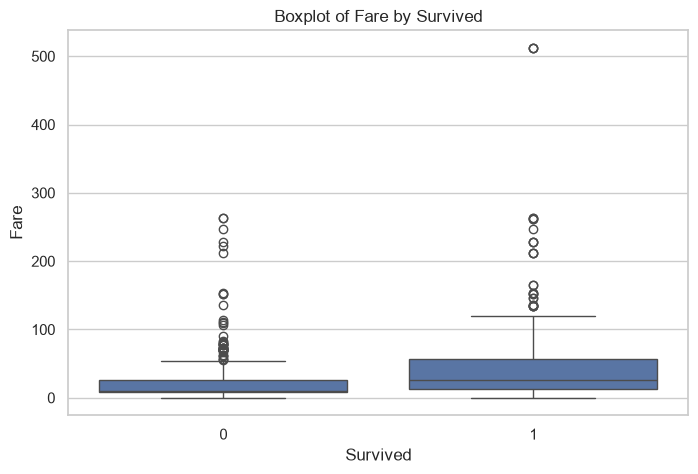

In [14]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='survived', y='fare')
plt.title('Boxplot of Fare by Survived')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

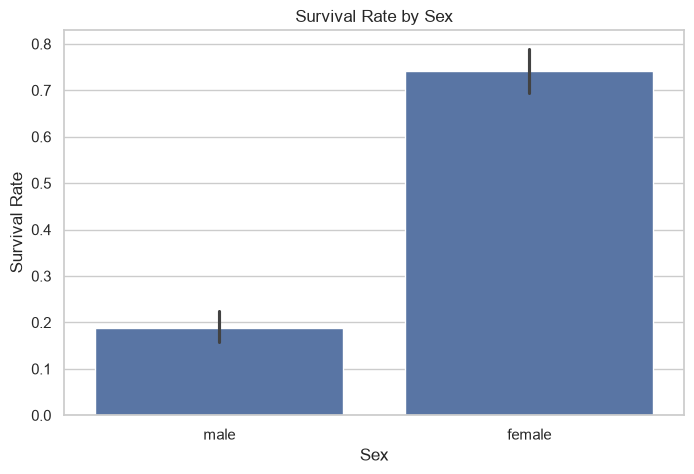

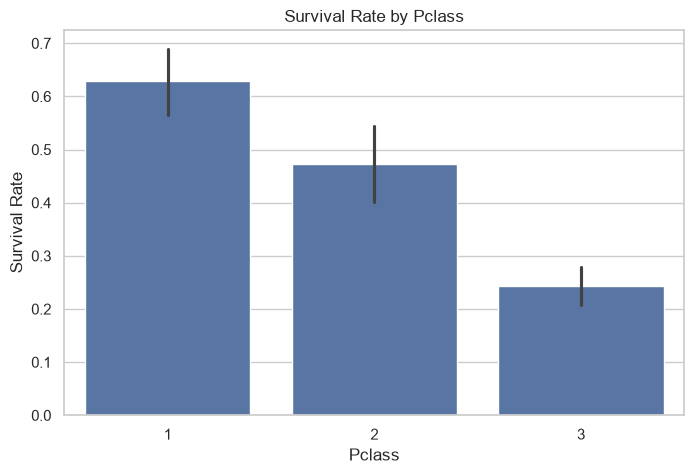

In [15]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='sex', y='survived')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='pclass', y='survived')
plt.title('Survival Rate by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.show()

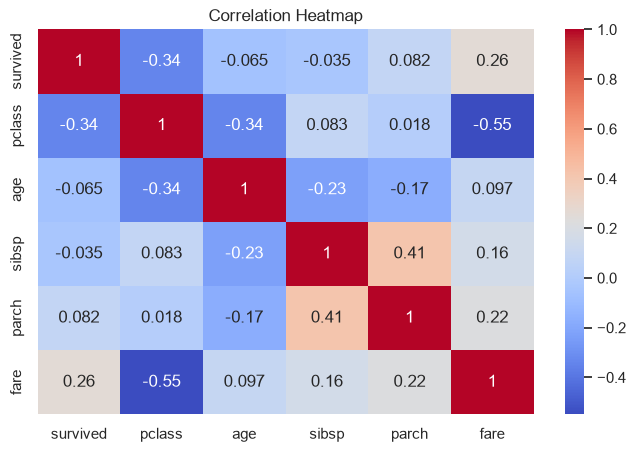

In [16]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Phân phối của age và fare đều lệch phải
- Boxplot: 
    - Median: trung vị của nhóm sống sót cao hơn của nhóm không sống sót ==> Hành khách mua vé đắt có xác suất sống sót cao hơn
    - Outliers: Các outliers đa số tập trung ở nhóm người sống sót ==> Hành khách mua vé siêu đắt có xác suất sống cao hơn ==> Giá vé có giá trị dự đoán lớn cho output
- Bar survival: 
    - Sex: Khả năng sống sót của nữ cao gấp 3 lần nam ==> Quy tắc ưu tiên phụ nữ 
    - Pclass: Vé hạng càng sang thì xác suất sống sót càng cao 
- Heatmap: Cặp parch-sibsp có tương quan dương mạnh nhất

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [17]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns='survived')
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size = 0.177, stratify=y_tmp, random_state=42)

print("Train/Val/Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# in tỷ lệ survived từng tập
print("Train survival rate:", y_train.mean())
print("Val survival rate:", y_val.mean())
print("Test survival rate:", y_test.mean()) 

Train/Val/Test: 623 134 134
Train survival rate: 0.38362760834670945
Val survival rate: 0.3880597014925373
Test survival rate: 0.3805970149253731


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [18]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot",  OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Fit chỉ trên tập train => mô hình không tiếp cận thông tin từ tập test => tránh leakage. 
Cụ thể, nếu fit trên tập test, các tham số như mean, std sẽ chứa thông tin từ tập test khiến kết quả đánh giá mô hình chính xác "ảo". Mô hình sẽ học vẹt các đặc điểm của tập test thay vì học quy luật logic giữa các biến, dẫn đến dự đoán sai khi đưa vào các dữ liệu không thuộc dataset.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [19]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
df['survived'].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

**Trả lời 8:**

1. Biến mục tiêu **survived** mất cân bằng, tỉ lệ không sống sót lớn hơn (gần gấp đôi) tỉ lệ sống sót

2. Nếu chỉ nhìn Accuracy, có thể bị đánh lừa trong trường hợp giả sử 90% không sống sót, 10% sống sót. Khi đó mô hình chỉ cần dự đoán người này không sống sót thì Accuracy là 90%

3. Với bài toán này, em chọn Recall. Bởi vì recall đo lường khả năng model tìm ra được bao nhiêu người thực sự sống trong tất cả người trên tàu. Model sẽ ít bỏ só hành khách hơn dù có thể dự đoán nhầm nhưng với việc cứu người thì dự đoán được càng nhiều người sống sót để ưu tiên cứu càng tốt. 

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Giá vé (fare) tương quan dương mạnh nhất với khả năng sống sót (Survived) với độ tương quan khoảng 0.26 (Task 5)

2. Cột Deck thiếu nhiều nhất (~77%) => Loại bỏ cột đó (Task 1)

3. Biến mục tiêu mất cân bằng, nghiêng về phía không sống sót (survived=0). Việc chọn metric là Accuracy có thể bị đánh lừa (ví dụ ở Task 8)

4. 
    - Đặc trưng cần scaling: Age, Fare
        - Nếu không chuẩn hóa, model sẽ coi cột fare quan trọng hơn cột age vì nó mang số lớn hơn
    - Đặc trưng cần encoding: Sex, Embarked
        - Vì thuật toán chỉ hiểu được các con số

5. Tuy fare tương quan dương mạnh với survived nhưng pclass tương quan âm mạnh với survived (vì hạng 1 con số nhỏ, hạng 3 là con số lớn) => Hạng vé càng thấp (số càng nhỏ) thì khả năng sống sót càng cao

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [20]:
# Chọn 1: Feature engineering
family_size = df['sibsp'] + df['parch'] + 1
df['family_size'] = family_size
correlation = df['survived'].corr(df['family_size'])
print(f"Correlation between 'survived' and 'family_size': {correlation:.4f}")  

Correlation between 'survived' and 'family_size': 0.0166


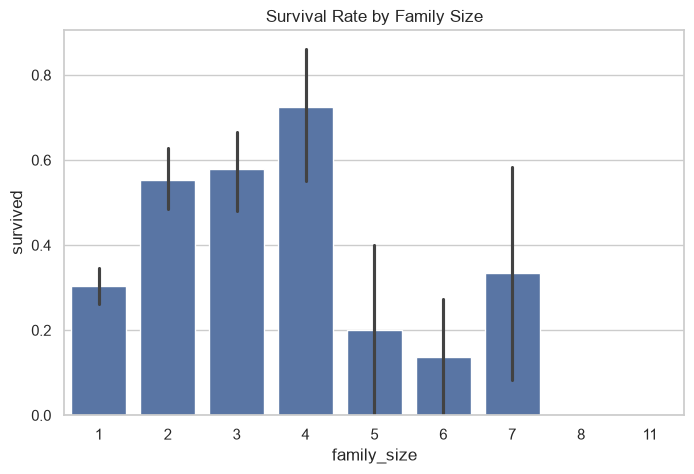

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='family_size', y='survived')
plt.title('Survival Rate by Family Size')
plt.show()

- Đi 1 mình có khả năng sống sót dưới trung bình
- Gia đình từ 2-4 người có khả năng sống sót cao nhất
- Gia đình từ 5 người trở lên khả năng sống sót giảm mạnh

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
